In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [11]:
df_train = pd.read_csv(r'D:\download\machine-learning-preprocessing\Feature_Engineering\Feature_Selection\test.csv\test.csv').drop(columns='subject')
df_test = pd.read_csv(r'D:\download\machine-learning-preprocessing\Feature_Engineering\Feature_Selection\test.csv\test.csv').drop(columns='subject')
df=pd.concat([df_train, df_test], axis=0)

In [12]:
print(df_train.shape, df_test.shape, df.shape)

(2947, 562) (2947, 562) (5894, 562)


In [14]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,STANDING


In [13]:
df['Activity'].value_counts()

Activity
LAYING                1074
STANDING              1064
WALKING                992
SITTING                982
WALKING_UPSTAIRS       942
WALKING_DOWNSTAIRS     840
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separate features and target
X_train = df_train.drop('Activity', axis=1)
y_train = df_train['Activity']
X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

# Encode target labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Applying Logistic Regression

In [18]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.995928062436376


### 1. Removing Duplicate Columns

In [19]:
def get_duplicate_columns(df):
    
    duplicate_columns = {}
    seen_columns = {}

    for column in df.columns:
        current_column = df[column]

        # Convert column data to bytes
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns

In [20]:
duplicate_columns = get_duplicate_columns(X_train)

In [21]:
duplicate_columns

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()',
  'tGravityAccMag-mean()',
  'tGravityAccMag-sma()'],
 'tBodyAccMag-std()': ['tGravityAccMag-std()'],
 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'],
 'tBodyAccMag-max()': ['tGravityAccMag-max()'],
 'tBodyAccMag-min()': ['tGravityAccMag-min()'],
 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'],
 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'],
 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'],
 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'],
 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'],
 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'],
 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'],
 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'],
 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'],
 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'],
 'fBodyAccMag-mean()': ['fBodyAccMag-sma()'],
 'fBodyBodyAccJerkMag-mean()': ['fBodyBodyAccJerkMag-sma()'],
 'fBodyBodyGyroMag-mean()': ['fBodyBodyGyroMag-sma()'

In [22]:
X_train[['tBodyAccMag-mean()','tBodyAccMag-sma()','tGravityAccMag-mean()','tGravityAccMag-sma()']]

,tBodyAccMag-mean(),tBodyAccMag-sma(),tGravityAccMag-mean(),tGravityAccMag-sma()
0,-0.866929,-0.866929,-0.866929,-0.866929
1,-0.968961,-0.968961,-0.968961,-0.968961
2,-0.976228,-0.976228,-0.976228,-0.976228
3,-0.974325,-0.974325,-0.974325,-0.974325
4,-0.975836,-0.975836,-0.975836,-0.975836
...,...,...,...,...
2942,-0.200885,-0.200885,-0.200885,-0.200885
2943,-0.170563,-0.170563,-0.170563,-0.170563
2944,-0.207603,-0.207603,-0.207603,-0.207603
2945,-0.233866,-0.233866,-0.233866,-0.233866


In [23]:
for one_list in duplicate_columns.values():
    X_train.drop(columns=one_list,inplace=True)
    X_test.drop(columns=one_list,inplace=True)

In [24]:
print(X_train.shape)
print(X_test.shape)

(2947, 540)
(2947, 540)


### 2. Variance Threshold

In [25]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.05)

In [26]:
sel.fit(X_train)

VarianceThreshold(threshold=0.05)

In [27]:
sum(sel.get_support())

np.int64(329)

In [28]:
columns = X_train.columns[sel.get_support()]

In [29]:
columns

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='str', length=329)

In [30]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [31]:
print(X_train.shape)
print(X_test.shape)

(2947, 329)
(2947, 329)


In [32]:
X_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,-0.554577,-0.466223,0.717208,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,-0.554577,-0.806013,0.768031,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,-0.568512,-0.799116,0.848305,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,-0.568512,-0.799116,0.848305,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,-0.560831,-0.825894,0.849179,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857


### 3. Correlation

In [33]:
import seaborn as sns

<Axes: >

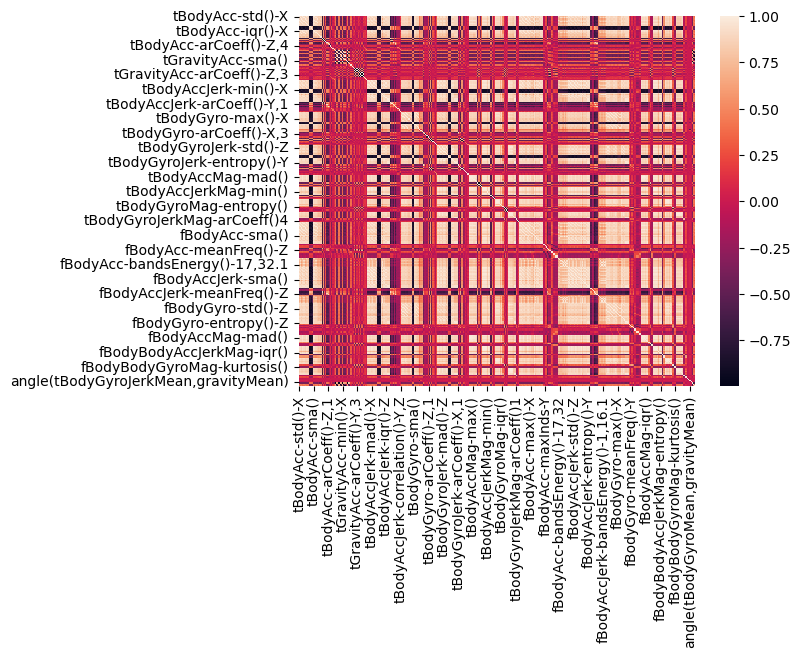

In [34]:
sns.heatmap(X_train.corr())

In [36]:
corr_matrix = X_train.corr()
corr_matrix

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
tBodyAcc-std()-X,1.000000,0.910636,0.896031,0.998828,0.904884,0.890581,0.983415,0.910462,0.900436,-0.960961,...,-0.076842,0.215845,0.189835,-0.032731,-0.004681,0.050398,-0.033609,-0.382696,0.401433,0.388747
tBodyAcc-std()-Y,0.910636,1.000000,0.874501,0.909197,0.997942,0.873176,0.894876,0.943786,0.884618,-0.910285,...,-0.122126,0.256692,0.227084,-0.021857,0.008462,0.027025,-0.018611,-0.383742,0.467572,0.405681
tBodyAcc-std()-Z,0.896031,0.874501,1.000000,0.893155,0.874238,0.997168,0.884270,0.863333,0.914841,-0.868658,...,-0.096371,0.238490,0.213969,-0.019312,-0.000485,0.034855,-0.029401,-0.383490,0.427469,0.488541
tBodyAcc-mad()-X,0.998828,0.909197,0.893155,1.000000,0.903653,0.887895,0.977487,0.908484,0.899089,-0.959452,...,-0.070142,0.217894,0.193008,-0.040846,-0.003577,0.050887,-0.033386,-0.381896,0.397630,0.386152
tBodyAcc-mad()-Y,0.904884,0.997942,0.874238,0.903653,1.000000,0.873640,0.888408,0.939725,0.882564,-0.907776,...,-0.115964,0.246244,0.217350,-0.025268,0.009091,0.020049,-0.015864,-0.380548,0.470157,0.406818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",0.050398,0.027025,0.034855,0.050887,0.020049,0.030782,0.054242,0.030906,-0.000201,-0.028279,...,-0.037128,0.057470,0.059126,-0.028812,0.014276,1.000000,-0.103693,-0.008413,0.004639,-0.004237
"angle(tBodyGyroJerkMean,gravityMean)",-0.033609,-0.018611,-0.029401,-0.033386,-0.015864,-0.029735,-0.035835,-0.006985,-0.002757,0.024480,...,-0.009320,0.000099,-0.003349,-0.043534,-0.004241,-0.103693,1.000000,0.026078,-0.000969,-0.031164
"angle(X,gravityMean)",-0.382696,-0.383742,-0.383490,-0.381896,-0.380548,-0.387125,-0.384454,-0.393966,-0.382246,0.367599,...,0.089237,-0.080410,-0.084848,-0.001915,0.003243,-0.008413,0.026078,1.000000,-0.668108,-0.615114
"angle(Y,gravityMean)",0.401433,0.467572,0.427469,0.397630,0.470157,0.428295,0.410477,0.427078,0.412152,-0.397998,...,-0.121717,0.086546,0.075210,0.006992,0.005806,0.004639,-0.000969,-0.668108,1.000000,0.425454


In [39]:
# Get the column names of the DataFrame
columns = corr_matrix.columns

# Create an empty list to keep track of columns to drop
columns_to_drop = []

# Loop over the columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        # Access the cell of the DataFrame
        if corr_matrix.loc[columns[i], columns[j]] > 0.95:
            columns_to_drop.append(columns[j])

print(len(columns_to_drop))

1430


In [40]:
columns_to_drop = set(columns_to_drop)

In [41]:
len(columns_to_drop)

180

In [43]:
X_train.drop(columns = columns_to_drop, inplace=True)
X_test.drop(columns = columns_to_drop, inplace=True)

In [44]:
print(X_train.shape)
print(X_test.shape)

(2947, 149)
(2947, 149)


### 4. ANOVA

In [45]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest


sel = SelectKBest(f_classif, k=100).fit(X_train, y_train)

# display selected feature names
X_train.columns[sel.get_support()]

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X',
       'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X',
       'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z',
       'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2',
       'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4',
       'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1',
       'tBodyAcc-correlation()-X,Y', 'tGravityAcc-mean()-X',
       'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z', 'tGravityAcc-sma()',
       'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z',
       'tGravityAcc-entropy()-X', 'tGravityAcc-arCoeff()-Y,1',
       'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Y,4',
       'tGravityAcc-arCoeff()-Z,1', 'tGravityAcc-arCoeff()-Z,2',
       'tBodyAccJerk-std()-Z', 'tBodyAccJerk-min()-X', 'tBodyAccJerk-min()-Y',
       'tBodyAccJerk-min()-Z', 'tBodyAccJerk-energy()-Y',
       'tBodyAccJerk-entropy()-X', 't

In [46]:
columns = X_train.columns[sel.get_support()]

In [47]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [48]:
print(X_train.shape)
print(X_test.shape)

(2947, 100)
(2947, 100)


In [49]:
X_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,...,fBodyGyro-skewness()-Z,fBodyAccMag-maxInds,fBodyAccMag-meanFreq(),fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyGyroMag-meanFreq(),"angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.938404,-0.920091,-0.667683,-0.554577,-0.466223,0.717208,0.635502,0.789497,-0.168084,-0.378996,...,-0.485654,-1.000000,-0.483453,-0.898100,-0.035356,-0.254248,-0.047391,-0.720009,0.276801,-0.057978
1,-0.975415,-0.967458,-0.944958,-0.554577,-0.806013,0.768031,0.683698,0.796706,-0.302437,-0.348243,...,-0.150220,-0.862069,0.203465,-0.967705,-0.491213,-0.215404,-0.031474,-0.698091,0.281343,-0.083898
2,-0.993819,-0.969926,-0.962748,-0.568512,-0.799116,0.848305,0.667864,0.822442,-0.617916,-0.695490,...,-0.566676,-1.000000,0.342456,-0.976358,0.140729,-0.206062,-0.168805,-0.702771,0.280083,-0.079346
3,-0.994743,-0.973268,-0.967091,-0.568512,-0.799116,0.848305,0.667864,0.822442,-0.749578,-0.899226,...,0.042241,-0.931034,0.331205,-0.995508,0.148649,-0.619905,-0.285636,-0.698954,0.284114,-0.077108
4,-0.993852,-0.967445,-0.978295,-0.560831,-0.825894,0.849179,0.670700,0.829897,-0.590576,-0.740206,...,-0.331464,-0.931034,0.071112,-0.988453,0.422249,-0.543096,-0.349061,-0.692245,0.290722,-0.073857


### Moment of Truth

In [50]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9803189684424839


### 5. Chi-square Test

In [3]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')[['Pclass','Sex','SibSp','Parch','Embarked','Survived']]
titanic.head()

,Pclass,Sex,SibSp,Parch,Embarked,Survived
0,3,male,1,0,S,0
1,1,female,1,0,C,1
2,3,female,0,0,S,1
3,1,female,1,0,S,1
4,3,male,0,0,S,0


In [4]:
ct = pd.crosstab(titanic['Survived'],titanic['Sex'],margins=True)
ct

Sex,female,male,All
Survived,,,
0,81,468,549
1,233,109,342
All,314,577,891


In [5]:
from scipy.stats import chi2_contingency
chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(263.05057407065567), pvalue=np.float64(1.0036732821369115e-55), dof=4, expected_freq=array([[193.47474747, 355.52525253, 549.        ],
       [120.52525253, 221.47474747, 342.        ],
       [314.        , 577.        , 891.        ]]))

The larger the value of chi2, the stronger the evidence that the two variables are associated (i.e., not independent).

In [15]:
score = []

for feature in titanic.columns[:-1]:
    
    # create contingency table
    ct = pd.crosstab(titanic['Survived'], titanic[feature])
    
    # chi_test
    p_value = chi2_contingency(ct)[1]
    score.append(p_value)

In [16]:
score

[np.float64(4.549251711298793e-23),
 np.float64(1.1973570627755645e-58),
 np.float64(1.5585810465902118e-06),
 np.float64(9.703526421039996e-05),
 np.float64(1.769922284120912e-06)]

<Axes: >

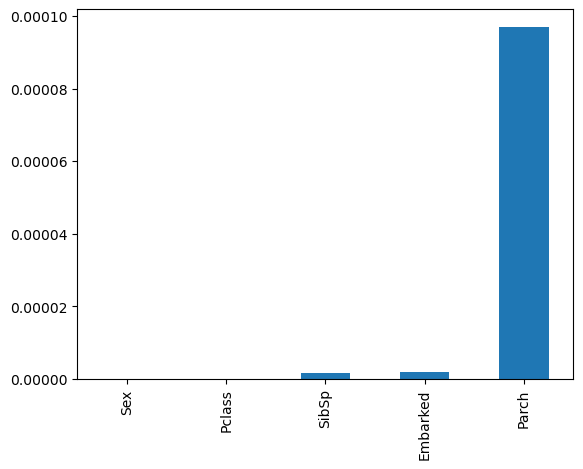

In [17]:
pd.Series(score, index=titanic.columns[:-1]).sort_values(ascending=True).plot(kind='bar')

## Using Sklearn

It automatically computes the contingency tables.

(array([54.46586599, 92.70244698,  1.23604038, 10.09749911,  9.75545583]), array([1.58171493e-13, 6.07783826e-22, 2.66235537e-01, 1.48470676e-03,
       1.78791305e-03]))


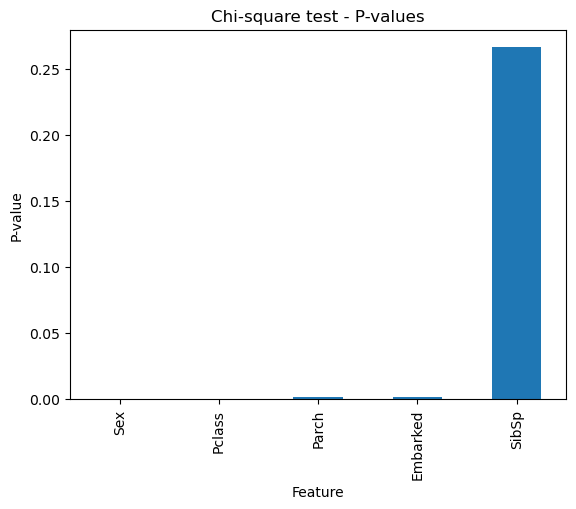

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

# assuming titanic is your DataFrame and 'Survived' is the target column

# Encode categorical variables
le = LabelEncoder()
titanic_encoded = titanic.apply(le.fit_transform)

X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

# Calculate chi-squared stats
chi_scores = chi2(X, y)
print(chi_scores)  # chi_scores[0] are the chi-squared stats,chi_scores[1] are the p-values of each feature.

# chi_scores[1] are the p-values of each feature.
p_values = pd.Series(chi_scores[1], index = X.columns)
p_values.sort_values(inplace = True)

# Plotting the p-values
p_values.plot.bar()

plt.title('Chi-square test - P-values')
plt.xlabel('Feature')
plt.ylabel('P-value')

plt.show()

# Mutual Information (MI)

Mutual Information (MI) is a **filter-based feature selection** technique that measures how much information a feature provides about the target variable.

- **Higher MI Score** → Strong relationship between feature and target.
- **MI = 0** → Feature and target are independent.
- Detects **both linear and non-linear** relationships.

---

## Formula

The Mutual Information between a feature \(X\) and target \(Y\) is:

$$
MI(X,Y)=\sum_{x}\sum_{y}
P(x,y)\log\left(\frac{P(x,y)}{P(x)P(y)}\right)
$$

where:

- \(P(x,y)\) = Joint probability of \(X\) and \(Y\)
- \(P(x)\) = Probability of \(X\)
- \(P(y)\) = Probability of \(Y\)

---

## Interpretation

- **MI = 0**
  - Feature and target are independent.
  - The feature provides no useful information.

- **Higher MI**
  - Knowing the feature significantly reduces uncertainty about the target.
  - The feature is more informative.

---

## Advantages

- Detects **linear and non-linear** relationships.
- Works for **classification** and **regression**.
- Suitable for **categorical** and **continuous** features.
- Does not assume a linear relationship.

---

## Limitations

- Does not indicate whether the relationship is **positive** or **negative**.
- MI scores are not standardized.
- Computationally more expensive than correlation.



In [24]:
import pandas as pd

data = {
    'A': ['a1', 'a2', 'a1', 'a1', 'a2', 'a1', 'a2', 'a2'],
    'B': ['b1', 'b2', 'b2', 'b1', 'b1', 'b2', 'b2', 'b1']
}

df = pd.DataFrame(data)

In [25]:
marginal_prob = pd.crosstab(df['A'], df['B'], margins=True, normalize='all')
marginal_prob

B,b1,b2,All
A,,,
a1,0.25,0.25,0.5
a2,0.25,0.25,0.5
All,0.50,0.50,1.0


In [26]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
import pandas as pd

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Compute mutual information
mi = mutual_info_classif(X, y)

# Print mutual information
for i, mi_value in enumerate(mi):
    print(f"Feature {i}: Mutual Information = {mi_value}")

Feature 0: Mutual Information = 0.48931762195134687
Feature 1: Mutual Information = 0.22353307870306605
Feature 2: Mutual Information = 0.9869963811932814
Feature 3: Mutual Information = 0.980985640218198


In [44]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Create SelectKBest feature selector
selector = SelectKBest(mutual_info_classif, k=2)

# Fit and transform
X_new = selector.fit_transform(X, y)

# Get columns to keep and create new dataframe with those only
cols = selector.get_support(indices=True)

print(iris.feature_names)
print(cols) 

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[2 3]
